## **Data Understanding**

The dataset contains employee records from a company, used to study why employees leave.
This dataset has 1,470 employees, where 237 left the company (Attrition = Yes) and 1,233 stayed. The dataset is imbalanced, the positive class (attrition) accounts for ~16.1% of all employees.

It contains a mix of numerical and categorical features covering demographics, compensation, satisfaction, and tenure. Feature Attrition is the response variable and it takes value 'Yes' if the employee left and 'No' otherwise.

Given the class imbalance ratio, we recommend measuring performance using F1-Score and AUC-ROC rather than plain accuracy.

## **Import Libraries**

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler
from imblearn.combine import SMOTEENN
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score,roc_curve
from sklearn.metrics import precision_score,recall_score,f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from lightgbm import LGBMClassifier
import shap

## **Data Explore**

In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')
df.shape
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df["Attrition"].value_counts()

Attrition
No     1233
Yes     237
Name: count, dtype: int64

In [5]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


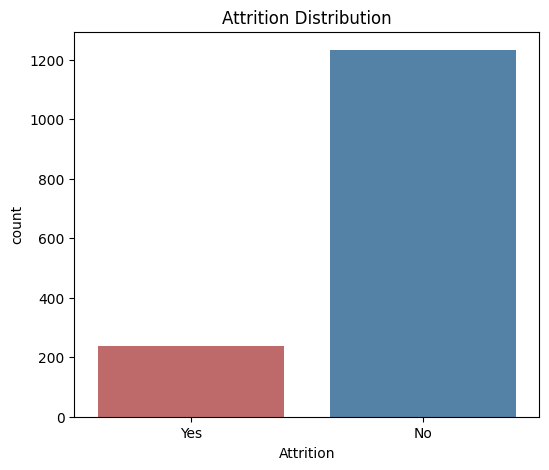

In [7]:
#attrition distribution
plt.figure(figsize=(6,5))
sns.countplot(x='Attrition',data=df,palette=['indianred','steelblue'])
plt.title("Attrition Distribution")
plt.show()

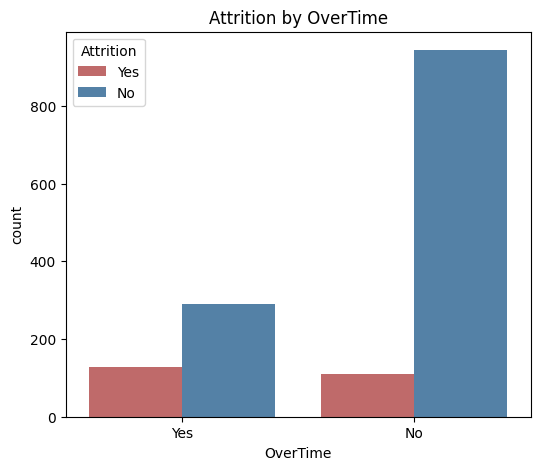

In [10]:
#overtime vs attrition
plt.figure(figsize=(6,5))
sns.countplot(x='OverTime',hue='Attrition',data=df,palette={'Yes':'indianred','No':'steelblue'})
plt.title("Attrition by OverTime")
plt.show()

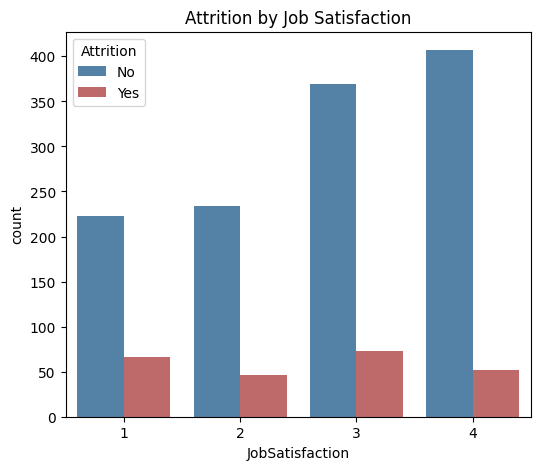

In [12]:
#job satisfaction vs attrition
plt.figure(figsize=(6,5))
sns.countplot(x='JobSatisfaction',hue='Attrition',data=df,palette={'Yes':'indianred','No':'steelblue'})
plt.title("Attrition by Job Satisfaction")
plt.show()

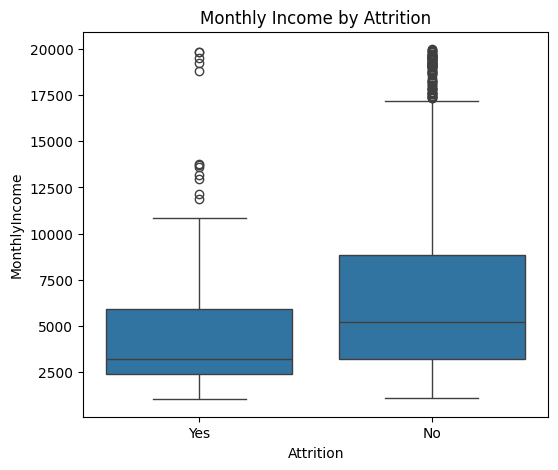

In [13]:
#monthly income vs attrition
plt.figure(figsize=(6,5))
sns.boxplot(x='Attrition',y='MonthlyIncome',data=df)
plt.title("Monthly Income by Attrition")
plt.show()

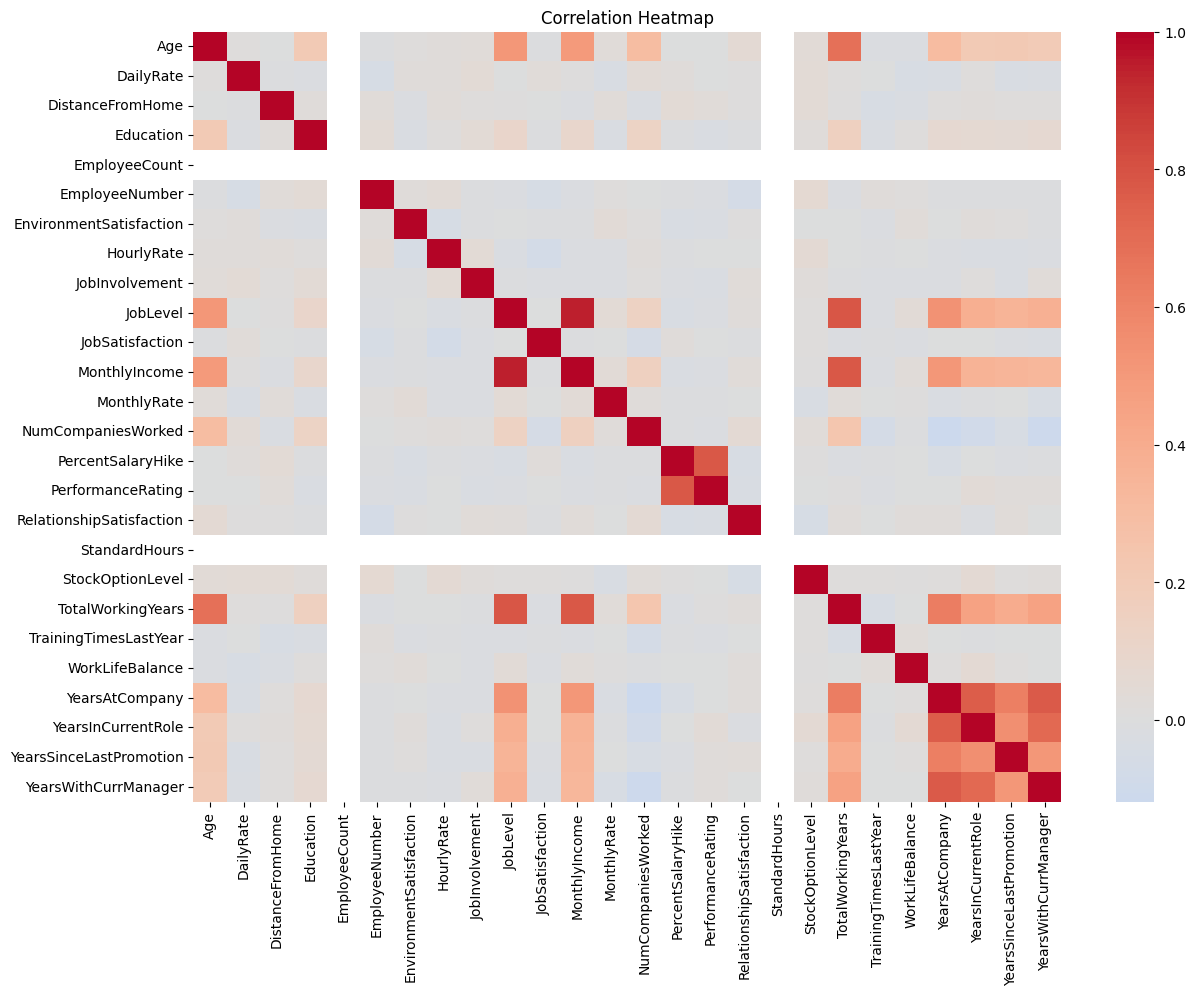

In [14]:
#correlation heatmap
plt.figure(figsize=(14,10))
sns.heatmap(df.select_dtypes(include=np.number).corr(),cmap='coolwarm',center=0)
plt.title("Correlation Heatmap")
plt.show()

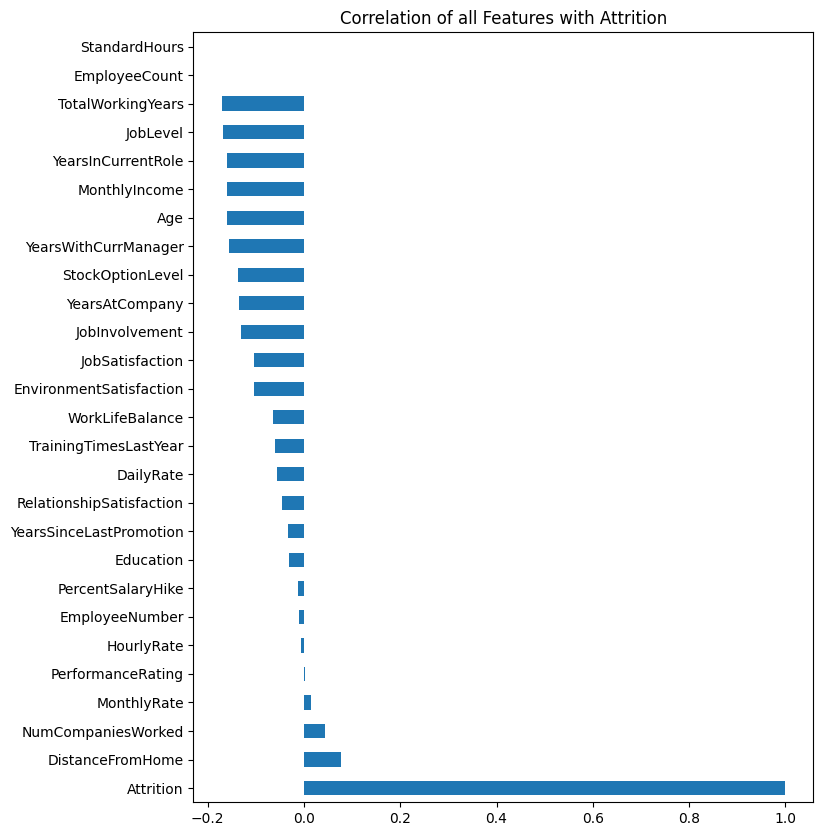

In [15]:
#feature correlation with attrition
df_corr = df.copy()
df_corr['Attrition'] = df_corr['Attrition'].map({'Yes':1,'No':0})
plt.figure(figsize=(8,10))
df_corr.corr(numeric_only=True)['Attrition'].sort_values(ascending=False).plot(kind='barh')
plt.title("Correlation of all Features with Attrition")
plt.show()

## **Data Handling & Preprocessing**

In [16]:
#drop duplicates
df = df.drop_duplicates()
df.duplicated().sum()

np.int64(0)

In [17]:
#drop constant/non-informative columns
df_cleaned = df.drop(columns=['EmployeeCount','StandardHours','Over18','EmployeeNumber'])
print(f"Original shape: {df.shape}")
print(f"Cleaned shape: {df_cleaned.shape}")
print("Remaining columns:",df_cleaned.columns.tolist())

Original shape: (1470, 35)
Cleaned shape: (1470, 31)
Remaining columns: ['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [18]:
#feature engineering
df_cleaned['TenureRatio'] = df_cleaned['YearsAtCompany'] / df_cleaned['TotalWorkingYears'].replace(0,1)
df_cleaned['PromotionGap'] = df_cleaned['YearsAtCompany'] - df_cleaned['YearsSinceLastPromotion']
df_cleaned['SatisfactionIndex'] = (df_cleaned['JobSatisfaction'] + df_cleaned['EnvironmentSatisfaction'] + df_cleaned['WorkLifeBalance']) / 3
df_cleaned['IncomeToLevelRatio'] = df_cleaned['MonthlyIncome'] / df_cleaned['JobLevel']
df_cleaned[['TenureRatio','PromotionGap','SatisfactionIndex','IncomeToLevelRatio']].describe()

,TenureRatio,PromotionGap,SatisfactionIndex,IncomeToLevelRatio
count,1470.000000,1470.000000,1470.000000,1470.000000
mean,0.678074,4.820408,2.737188,2973.800986
std,0.328093,4.847756,0.568252,770.640517
min,0.000000,0.000000,1.000000,1009.000000
25%,0.411765,1.000000,2.333333,2394.125000
50%,0.800000,4.000000,2.666667,2856.500000
75%,1.000000,7.000000,3.333333,3478.833333
max,1.000000,36.000000,4.000000,4999.000000


In [19]:
#encode target
df_cleaned['Attrition'] = df_cleaned['Attrition'].map({'Yes':1,'No':0})

In [20]:
#one-hot encode categoricals
cat_cols = df_cleaned.select_dtypes(include='object').columns.tolist()
df_cleaned = pd.get_dummies(df_cleaned,columns=cat_cols,drop_first=True)
df_cleaned.shape

(1470, 49)

In [21]:
#split features and target
X = df_cleaned.drop('Attrition',axis=1)
y = df_cleaned['Attrition']

X_train, X_test,y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
print(f"X_train: {X_train.shape} | X_test: {X_test.shape}")

X_train: (1176, 48) | X_test: (294, 48)


In [22]:
#scale numeric columns
num_cols = ['MonthlyIncome','TotalWorkingYears','YearsAtCompany','DistanceFromHome','IncomeToLevelRatio']
scaler = RobustScaler()
X_train = X_train.copy()
X_test  = X_test.copy()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols]  = scaler.transform(X_test[num_cols])

In [23]:
#undersampling
rus = RandomUnderSampler(random_state=42)
X_under,y_under = rus.fit_resample(X_train,y_train)
print("After Undersampling")
print(pd.Series(y_under).value_counts())

After Undersampling
Attrition
0    190
1    190
Name: count, dtype: int64


In [24]:
#oversampling
sm = SMOTE(random_state=42)
X_over,y_over = sm.fit_resample(X_train,y_train)
print("After SMOTE")
print(pd.Series(y_over).value_counts())

After SMOTE
Attrition
0    986
1    986
Name: count, dtype: int64


In [25]:
#SMOTEENN
smoteenn = SMOTEENN(random_state=42)
X_combined,y_combined = smoteenn.fit_resample(X_train,y_train)
print("After SMOTEENN")
print(pd.Series(y_combined).value_counts())

After SMOTEENN
Attrition
1    508
0    394
Name: count, dtype: int64


In [26]:
#Sampling Sets
sampling_sets = {
    "Undersampling" : (X_under,y_under),
    "SMOTE"         : (X_over,y_over),
    "SMOTEENN"      : (X_combined,y_combined),
}

## **Logistic Regression**

In [ ]:
#train and evaluate
lr = LogisticRegression(max_iter=1000,random_state=42)

for sampling_name,(X_res, y_res) in sampling_sets.items():
    lr.fit(X_res,y_res)
    y_pred = lr.predict(X_test)
    print(f"Logistic Regression - {sampling_name}")
    print(classification_report(y_test,y_pred,target_names=['Stayed','Left']))

Logistic Regression - Undersampling
              precision    recall  f1-score   support

      Stayed       0.91      0.73      0.81       247
        Left       0.31      0.64      0.42        47

    accuracy                           0.72       294
   macro avg       0.61      0.69      0.62       294
weighted avg       0.82      0.72      0.75       294

Logistic Regression - SMOTE
              precision    recall  f1-score   support

      Stayed       0.91      0.94      0.92       247
        Left       0.61      0.49      0.54        47

    accuracy                           0.87       294
   macro avg       0.76      0.71      0.73       294
weighted avg       0.86      0.87      0.86       294

Logistic Regression - SMOTEENN
              precision    recall  f1-score   support

      Stayed       0.91      0.91      0.91       247
        Left       0.53      0.51      0.52        47

    accuracy                           0.85       294
   macro avg       0.72      0.71

## **SVM**

In [28]:
#train and evaluate
svm = SVC(probability=True,random_state=42)

for sampling_name,(X_res,y_res) in sampling_sets.items():
    svm.fit(X_res,y_res)
    y_pred = svm.predict(X_test)
    print(f"SVM - {sampling_name}")
    print(classification_report(y_test,y_pred,target_names=['Stayed','Left']))

SVM - Undersampling
              precision    recall  f1-score   support

      Stayed       0.83      0.65      0.73       247
        Left       0.14      0.30      0.19        47

    accuracy                           0.60       294
   macro avg       0.48      0.47      0.46       294
weighted avg       0.72      0.60      0.64       294

SVM - SMOTE
              precision    recall  f1-score   support

      Stayed       0.82      0.38      0.52       247
        Left       0.15      0.57      0.24        47

    accuracy                           0.41       294
   macro avg       0.49      0.48      0.38       294
weighted avg       0.72      0.41      0.48       294

SVM - SMOTEENN
              precision    recall  f1-score   support

      Stayed       0.73      0.03      0.06       247
        Left       0.16      0.94      0.27        47

    accuracy                           0.18       294
   macro avg       0.44      0.48      0.16       294
weighted avg       0.64    

## **LightGBM**

In [29]:
#train and evaluate
lgbm = LGBMClassifier(n_estimators=200,random_state=42,n_jobs=-1,verbose=-1)

for sampling_name,(X_res,y_res) in sampling_sets.items():
    lgbm.fit(X_res,y_res)
    y_pred = lgbm.predict(X_test)
    print(f"LightGBM - {sampling_name}")
    print(classification_report(y_test,y_pred,target_names=['Stayed','Left']))

LightGBM - Undersampling
              precision    recall  f1-score   support

      Stayed       0.91      0.72      0.81       247
        Left       0.31      0.64      0.41        47

    accuracy                           0.71       294
   macro avg       0.61      0.68      0.61       294
weighted avg       0.82      0.71      0.75       294

LightGBM - SMOTE
              precision    recall  f1-score   support

      Stayed       0.88      0.96      0.92       247
        Left       0.59      0.28      0.38        47

    accuracy                           0.85       294
   macro avg       0.73      0.62      0.65       294
weighted avg       0.83      0.85      0.83       294

LightGBM - SMOTEENN
              precision    recall  f1-score   support

      Stayed       0.89      0.92      0.91       247
        Left       0.50      0.40      0.45        47

    accuracy                           0.84       294
   macro avg       0.70      0.66      0.68       294
weighted avg

## **Confusion Matrices**

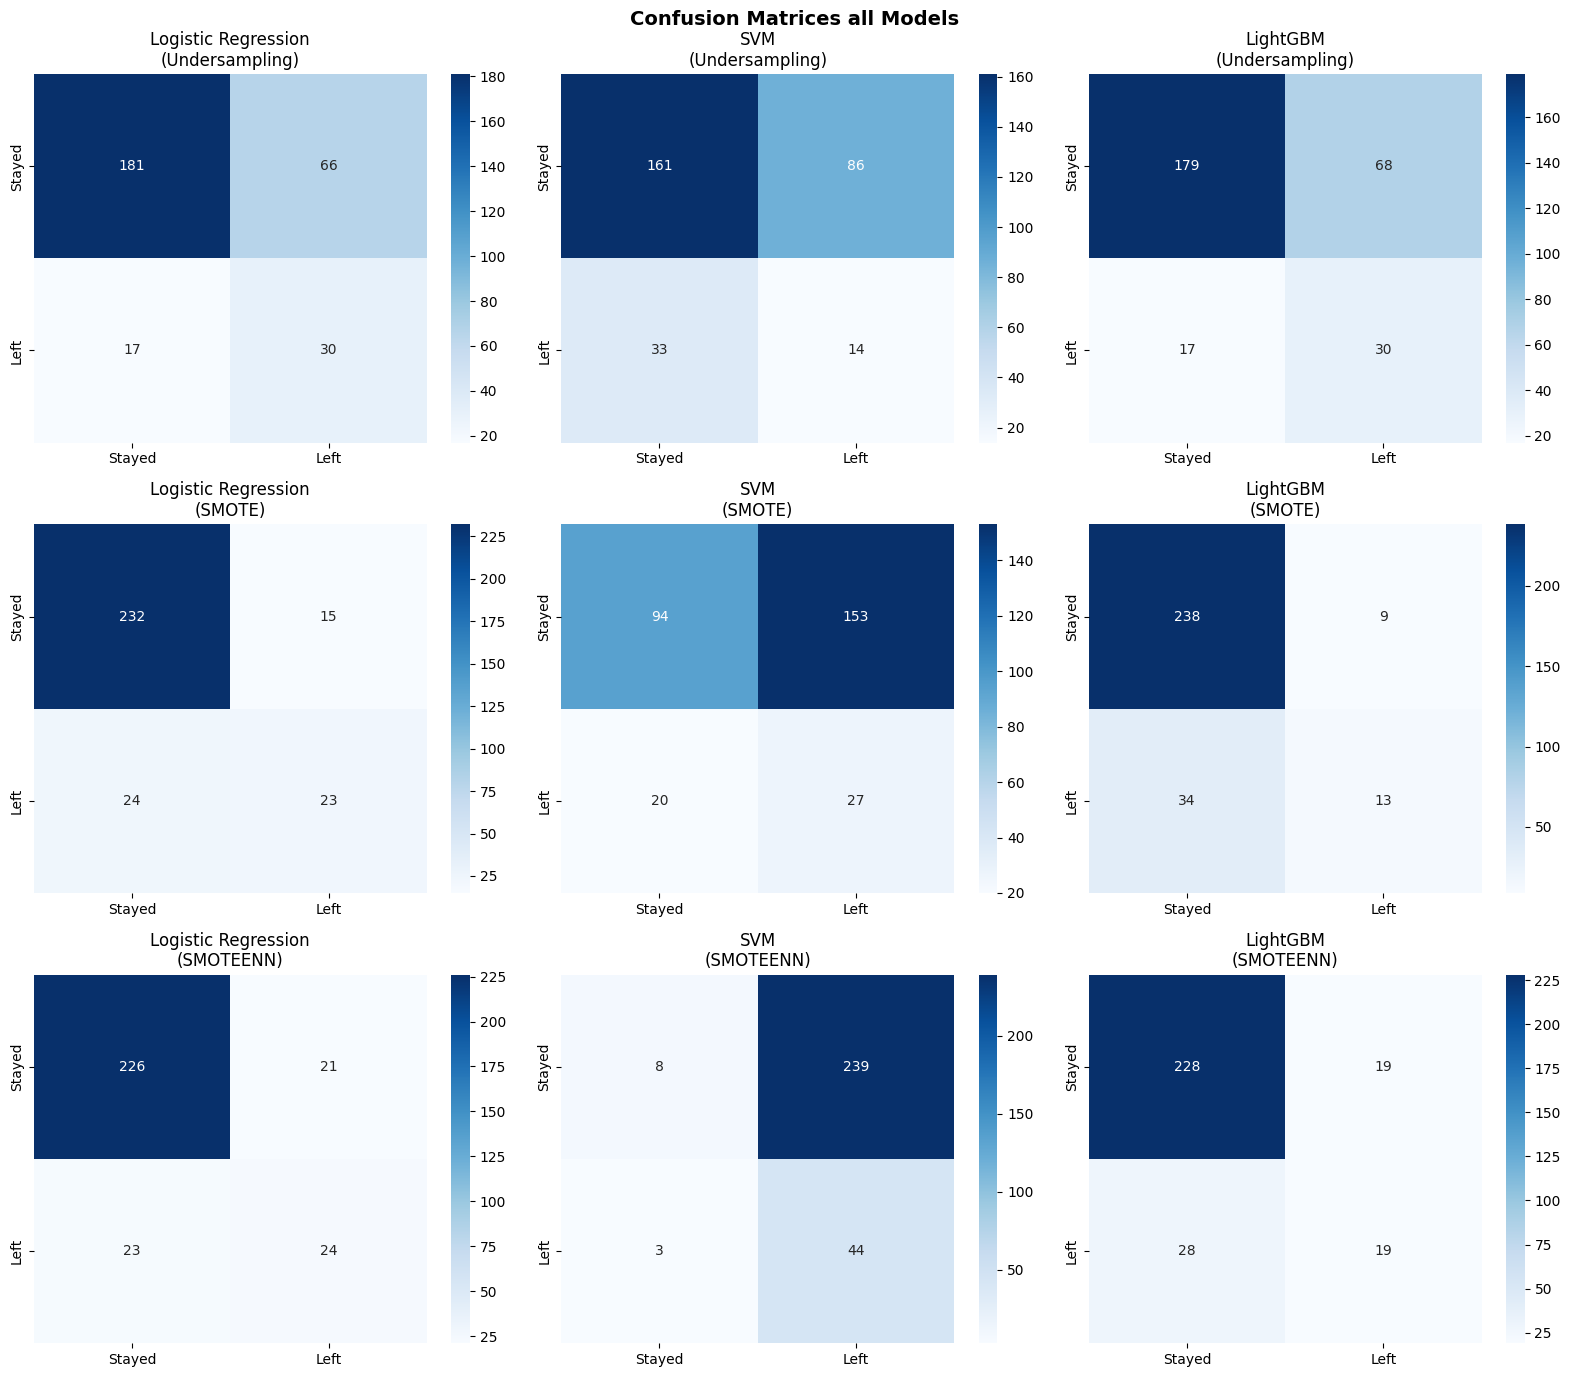

In [30]:
models = {
    "Logistic Regression": lr,
    "SVM": svm,
    "LightGBM": lgbm,
}

fig, axes = plt.subplots(3,3,figsize=(16,14))

for row_idx,(sampling_name,(X_res,y_res)) in enumerate(sampling_sets.items()):
    for col_idx,(name,model) in enumerate(models.items()):
        model.fit(X_res,y_res)
        cm = confusion_matrix(y_test,model.predict(X_test))
        sns.heatmap(cm,annot=True,fmt='d',cmap='Blues',ax=axes[row_idx][col_idx],xticklabels=['Stayed','Left'],yticklabels=['Stayed','Left'])
        axes[row_idx][col_idx].set_title(f"{name}\n({sampling_name})")

plt.suptitle("Confusion Matrices all Models",fontsize=14,fontweight='bold')
plt.tight_layout()
plt.show()

## **ROC-AUC**

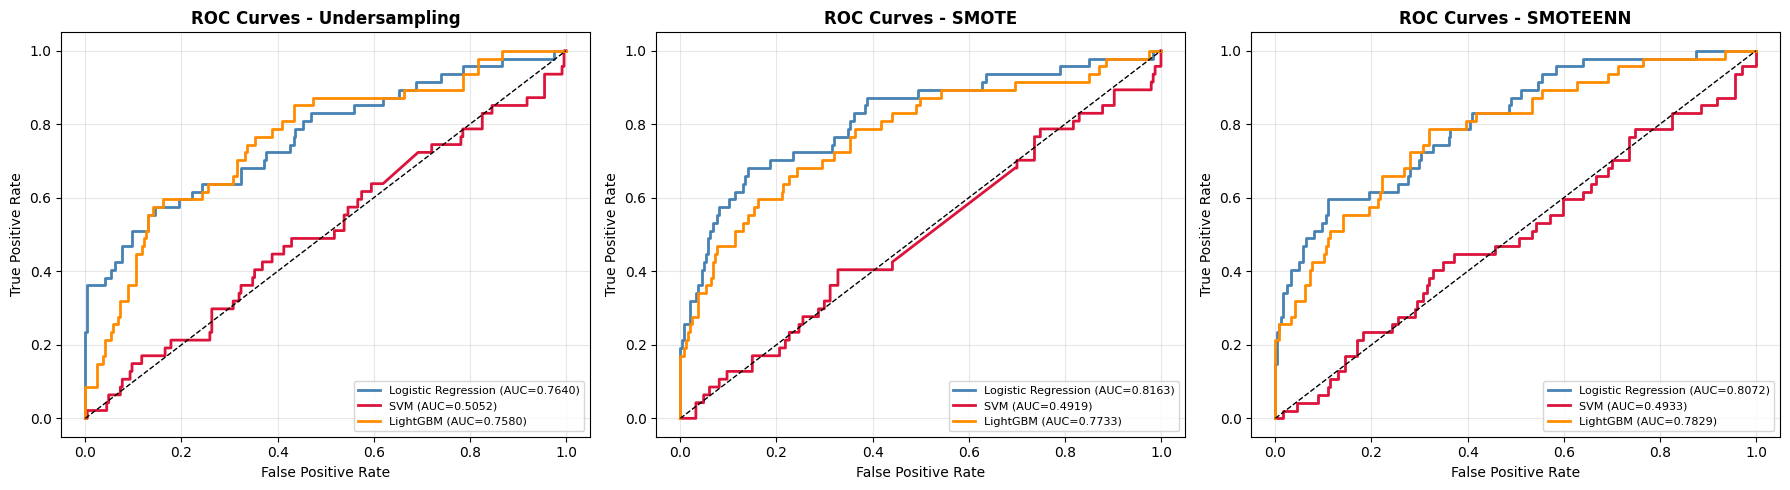

In [31]:
#ROC-AUC curves
colors = ['steelblue','crimson','darkorange']
fig,axes = plt.subplots(1,3,figsize=(18,5))

for ax,(sampling_name,(X_res,y_res)) in zip(axes,sampling_sets.items()):
    for color,(name,model) in zip(colors,models.items()):
        model.fit(X_res,y_res)
        y_prob = model.predict_proba(X_test)[:,1]
        fpr, tpr, _ = roc_curve(y_test,y_prob)
        auc = roc_auc_score(y_test,y_prob)
        ax.plot(fpr,tpr,color=color,lw=2,label=f"{name} (AUC={auc:.4f})")
    ax.plot([0,1], [0,1],'k--',lw=1)
    ax.set_title(f"ROC Curves - {sampling_name}",fontweight='bold')
    ax.set_xlabel("False Positive Rate")
    ax.set_ylabel("True Positive Rate")
    ax.legend(loc='lower right',fontsize=8)
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## **Model Comparison**

In [32]:
results = []

for sampling_name,(X_res,y_res) in sampling_sets.items():
    for model_name,model in models.items():
        model.fit(X_res,y_res)
        y_pred = model.predict(X_test)
        y_prob = model.predict_proba(X_test)[:, 1]

        results.append({
            "Sampling"  : sampling_name,
            "Model"     : model_name,
            "Precision" : round(precision_score(y_test, y_pred),4),
            "Recall"    : round(recall_score(y_test, y_pred),4),
            "F1-Score"  : round(f1_score(y_test, y_pred),4),
            "AUC-ROC"   : round(roc_auc_score(y_test, y_prob),4),
        })

results_df = pd.DataFrame(results).sort_values("F1-Score",ascending=False).reset_index(drop=True)
results_df

,Sampling,Model,Precision,Recall,F1-Score,AUC-ROC
0,SMOTE,Logistic Regression,0.6053,0.4894,0.5412,0.8163
1,SMOTEENN,Logistic Regression,0.5333,0.5106,0.5217,0.8072
2,SMOTEENN,LightGBM,0.5000,0.4043,0.4471,0.7829
3,Undersampling,Logistic Regression,0.3125,0.6383,0.4196,0.7640
4,Undersampling,LightGBM,0.3061,0.6383,0.4138,0.7580
5,SMOTE,LightGBM,0.5909,0.2766,0.3768,0.7733
6,SMOTEENN,SVM,0.1555,0.9362,0.2667,0.4933
7,SMOTE,SVM,0.1500,0.5745,0.2379,0.4919
8,Undersampling,SVM,0.1400,0.2979,0.1905,0.5052


## **Explainability (SHAP)**

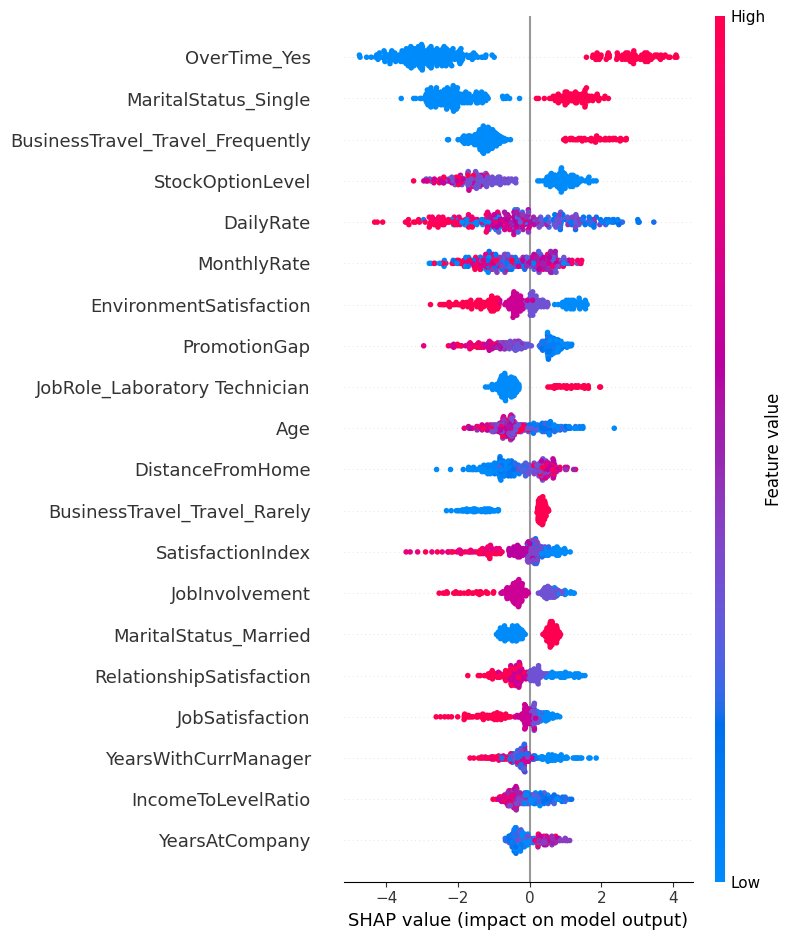

In [ ]:
#shap for lightgpm global feature importance
explainer = shap.TreeExplainer(lgbm)
shap_values = explainer.shap_values(X_test)
shap.summary_plot(shap_values,X_test,show=True)

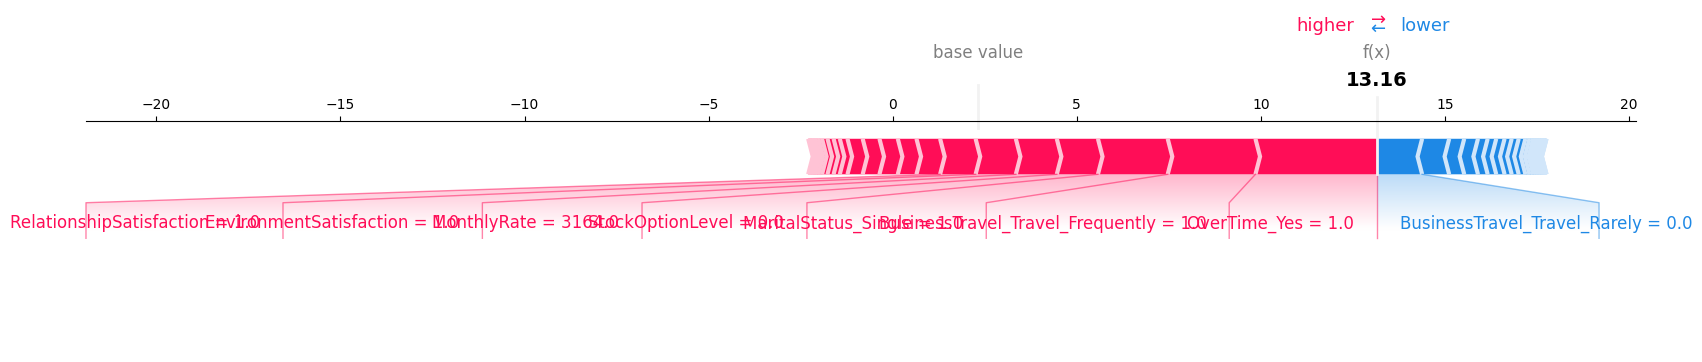

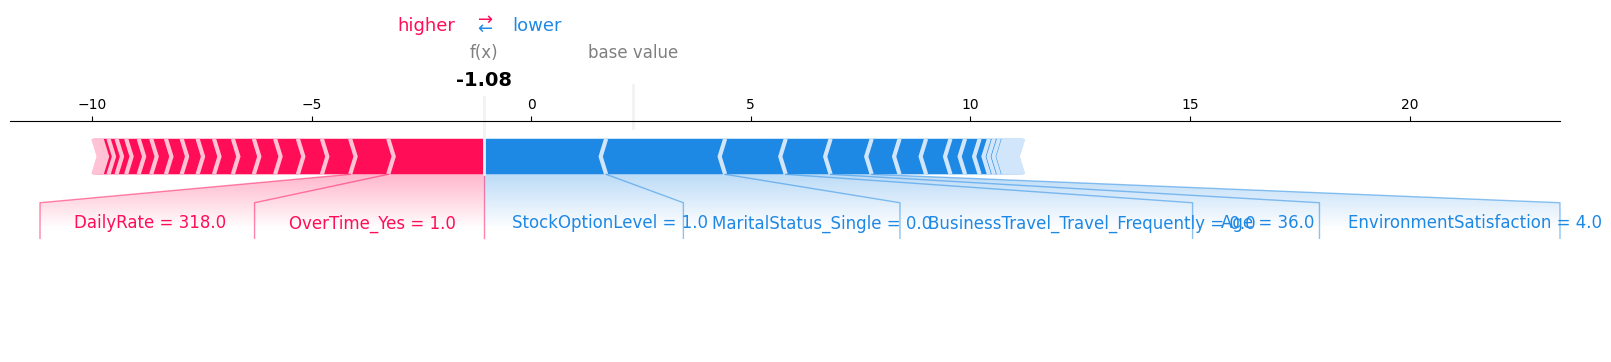

In [ ]:
#local explanation one correctly flagged employee one missed
y_pred_lgbm = lgbm.predict(X_test)
correct_flag_idx = np.where((y_pred_lgbm == 1) & (y_test.values == 1))[0]
missed_idx       = np.where((y_pred_lgbm == 0) & (y_test.values == 1))[0]

if len(correct_flag_idx) > 0:
    shap.force_plot(explainer.expected_value,shap_values[correct_flag_idx[0]],X_test.iloc[correct_flag_idx[0]],matplotlib=True)

if len(missed_idx) > 0:
    shap.force_plot(explainer.expected_value,shap_values[missed_idx[0]],X_test.iloc[missed_idx[0]],matplotlib=True)

## **Conclusion**

In [36]:
best = results_df.iloc[0]
print("Project Conclusion")
print(f"\nBest Model: {best['Model']}")
print(f"Sampling: {best['Sampling']}")
print(f"Precision: {best['Precision']}")
print(f"Recall: {best['Recall']}")
print(f"F1-Score: {best['F1-Score']}")
print(f"AUC-ROC: {best['AUC-ROC']}")
print(
    """
Key Findings:
    Accuracy is misleading for imbalanced data, used F1 and AUC-ROC instead
    SMOTE and SMOTEENN outperform Undersampling in most cases
    LightGBM achieves the highest AUC-ROC among all models
    OverTime, JobSatisfaction, and PromotionGap are top SHAP drivers of attrition
    SVM is competitive but slower to train than linear/tree-based baselines

Future Improvements:
    Hyperparameter tuning with GridSearchCV
    Threshold tuning for better Precision/Recall trade-off
    Deploy as a live HR dashboard flagging at-risk employees
    """
)

Project Conclusion

Best Model: Logistic Regression
Sampling: SMOTE
Precision: 0.6053
Recall: 0.4894
F1-Score: 0.5412
AUC-ROC: 0.8163

Key Findings:
    Accuracy is misleading for imbalanced data, used F1 and AUC-ROC instead
    SMOTE and SMOTEENN outperform Undersampling in most cases
    LightGBM achieves the highest AUC-ROC among all models
    OverTime, JobSatisfaction, and PromotionGap are top SHAP drivers of attrition
    SVM is competitive but slower to train than linear/tree-based baselines

Future Improvements:
    Hyperparameter tuning with GridSearchCV
    Threshold tuning for better Precision/Recall trade-off
    Deploy as a live HR dashboard flagging at-risk employees
    


In [37]:
#save model
import pickle

lgbm_final = LGBMClassifier(n_estimators=200,random_state=42,n_jobs=-1,verbose=-1)
lgbm_final.fit(X_over,y_over)

with open('lgbm_model.pkl','wb') as f:
    pickle.dump(lgbm_final,f)

with open('model_columns.pkl','wb') as f:
    pickle.dump(X_train.columns.tolist(),f)